In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error

In [3]:
#data imported from csv file 
df=pd.read_csv('Salary_Data.csv') 
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [4]:
# Extracting the Independent and Dependent Variables
X=df.iloc[:, :-1].values
y=df.iloc[:, -1].values
print(X)
print(y)

[[ 1.1]
 [ 1.3]
 [ 1.5]
 [ 2. ]
 [ 2.2]
 [ 2.9]
 [ 3. ]
 [ 3.2]
 [ 3.2]
 [ 3.7]
 [ 3.9]
 [ 4. ]
 [ 4. ]
 [ 4.1]
 [ 4.5]
 [ 4.9]
 [ 5.1]
 [ 5.3]
 [ 5.9]
 [ 6. ]
 [ 6.8]
 [ 7.1]
 [ 7.9]
 [ 8.2]
 [ 8.7]
 [ 9. ]
 [ 9.5]
 [ 9.6]
 [10.3]
 [10.5]]
[ 39343.  46205.  37731.  43525.  39891.  56642.  60150.  54445.  64445.
  57189.  63218.  55794.  56957.  57081.  61111.  67938.  66029.  83088.
  81363.  93940.  91738.  98273. 101302. 113812. 109431. 105582. 116969.
 112635. 122391. 121872.]


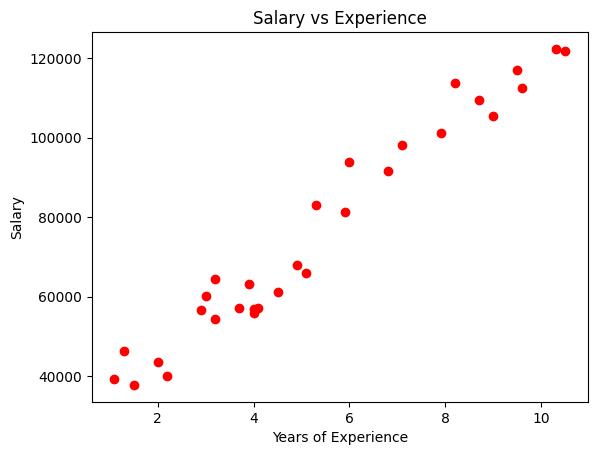

In [5]:
#checking linear or not
plt.scatter(X,y, color='red')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs Experience')
plt.show()

In [6]:
# Splitting the dataset into the Training set and Test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=0)
print(X_train)
print(X_test)

[[ 2.9]
 [ 5.1]
 [ 3.2]
 [ 4.5]
 [ 8.2]
 [ 6.8]
 [ 1.3]
 [10.5]
 [ 3. ]
 [ 2.2]
 [ 5.9]
 [ 6. ]
 [ 3.7]
 [ 3.2]
 [ 9. ]
 [ 2. ]
 [ 1.1]
 [ 7.1]
 [ 4.9]
 [ 4. ]]
[[ 1.5]
 [10.3]
 [ 4.1]
 [ 3.9]
 [ 9.5]
 [ 8.7]
 [ 9.6]
 [ 4. ]
 [ 5.3]
 [ 7.9]]


In [7]:
# Fitting Simple Linear Regression to the Training set
lin_reg=LinearRegression()
lin_reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
# Predicting the Test set results
y_pred=lin_reg.predict(X_test)
print(y_pred)

[ 40835.10590871 123079.39940819  65134.55626083  63265.36777221
 115602.64545369 108125.8914992  116537.23969801  64199.96201652
  76349.68719258 100649.1375447 ]


<Axes: ylabel='Density'>

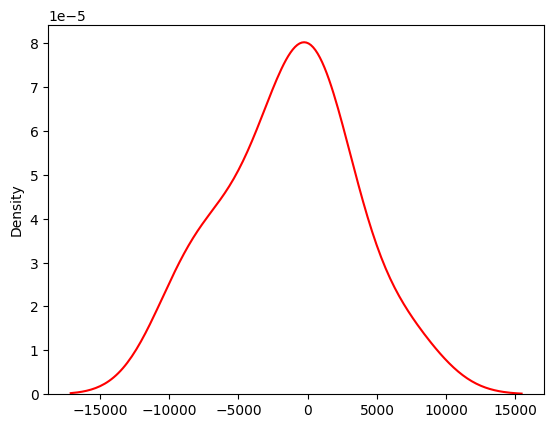

In [9]:
#checking normal residual
residual=y_test-y_pred
sns.kdeplot(residual, color='red')

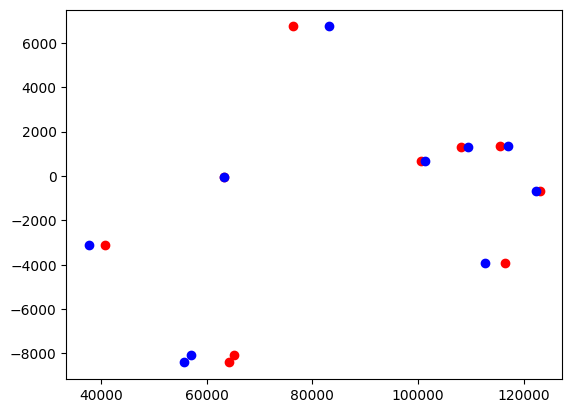

In [10]:
#checking homoscedasticity
plt.scatter(y_pred, residual, color='red')
plt.scatter(y_test, residual, color='blue')

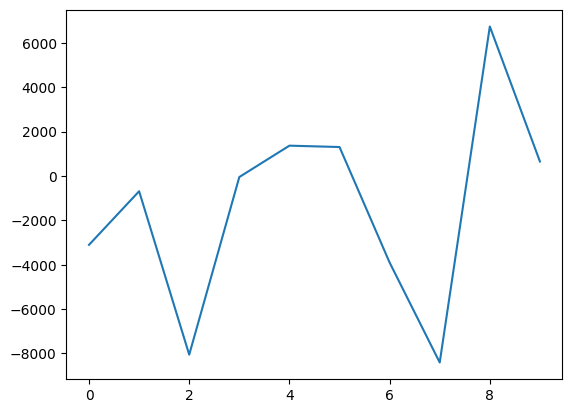

In [11]:
#checking auto-correlation
plt.plot(residual)

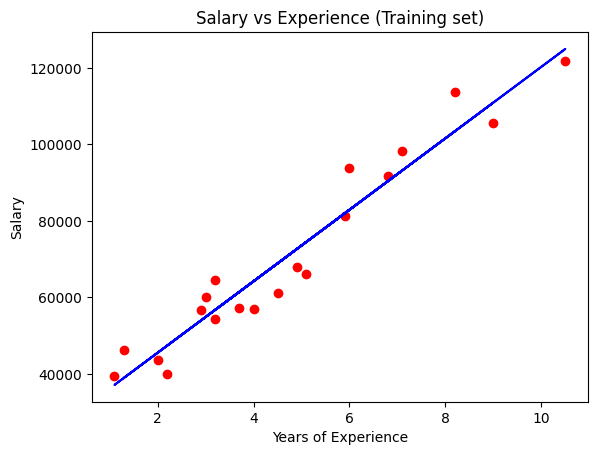

In [15]:
# Visualising the Training set results
plt.scatter(X_train, y_train, color='red')
plt.plot(X_train, lin_reg.predict(X_train), color='blue')
plt.title('Salary vs Experience (Training set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.savefig('trg_set_vs_reg_line.png')
plt.show()

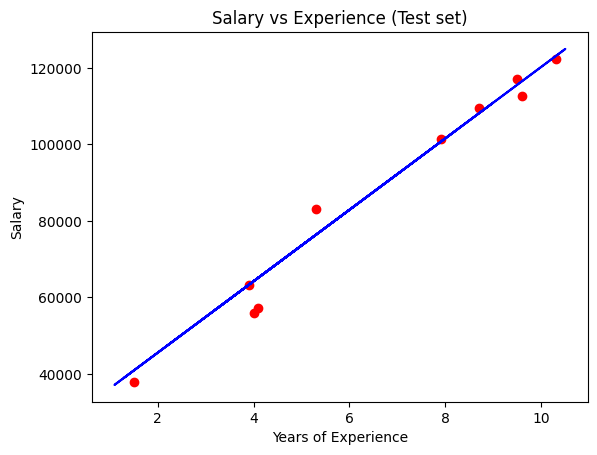

In [16]:
#Visualising the Test set results
plt.scatter(X_test, y_test, color='red')
plt.plot(X_train, lin_reg.predict(X_train), color='blue')
plt.title('Salary vs Experience (Test set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.savefig('test_set_vs_reg_line.png')
plt.show()

In [14]:
#checking evaluation metrics
r2score=r2_score(y_test, y_pred)
print(f"R² Score: {r2score}")
rmse=root_mean_squared_error(y_test, y_pred)
print(f"rmse value: {rmse}") 

R² Score: 0.9749154407708353
rmse value: 4585.4157204675885
